TF-IDF (Term Frequency – Inverse Document Frequency)

SVM (Support Vector Machine)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import joblib

In [ ]:
train_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/train.csv"
)

val_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/val.csv"
)

test_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/test.csv"
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(800, 2)
(100, 2)
(100, 2)


In [ ]:
X_train = train_df["Sample_Code"]
y_train = train_df["Label"]

X_val = val_df["Sample_Code"]
y_val = val_df["Label"]

X_test = test_df["Sample_Code"]
y_test = test_df["Label"]

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2), #Unigram & Bigram
    lowercase=False,
    min_df=2
)

In [ ]:
X_train_tfidf = vectorizer.fit_transform(
    X_train
) # belajar pola vocabulary + transformasi

X_val_tfidf = vectorizer.transform(
    X_val #  hanya transformasi (jangan belajar ulang)

)

X_test_tfidf = vectorizer.transform(
    X_test #  hanya transformasi (jangan belajar ulang)

)

In [ ]:
print(X_train_tfidf.shape)
print(X_val_tfidf.shape)
print(X_test_tfidf.shape)

(800, 5000)
(100, 5000)
(100, 5000)


In [ ]:
svm_model = SVC(
    kernel="linear", # menggunakan hyperplane linear untuk memisahkan Human dan AI
    C=1, # mengatur keseimbangan antara margin dan kesalahan klasifikasi
    probability=True, # menghasilkan probabilitas prediksi untuk ROC dan AUC
    random_state=42 # memastikan hasil eksperimen dapat direproduksi
)

In [ ]:
import time

start = time.time()

svm_model.fit(
    X_train_tfidf,
    y_train
)

end = time.time()

print(
    "Training Time:",
    round(end-start,2),
    "seconds"
)

Training Time: 1.62 seconds


In [ ]:
val_pred = svm_model.predict(
    X_val_tfidf
)

val_acc = accuracy_score(
    y_val,
    val_pred
)

print(
    "Validation Accuracy:",
    round(val_acc,4)
)

Validation Accuracy: 0.96


In [ ]:
print(
    classification_report(
        y_val,
        val_pred,
        target_names=[
            "Human",
            "AI"
        ]
    )
)

              precision    recall  f1-score   support

       Human       0.98      0.94      0.96        50
          AI       0.94      0.98      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



In [ ]:
# Probability untuk kelas AI (label 1)

y_prob = svm_model.predict_proba(
    X_test_tfidf
)[:,1]

# Hitung AUC

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"AUC Score: {auc_score:.4f}"
)

AUC Score: 0.9688


In [ ]:
test_pred = svm_model.predict(
    X_test_tfidf
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print(
    "Test Accuracy:",
    round(test_acc,4)
)

precision = precision_score(
    y_test,
    test_pred
)

recall = recall_score(
    y_test,
    test_pred
)

f1 = f1_score(
    y_test,
    test_pred
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "Human",
            "AI"
        ]
    )
)

Test Accuracy: 0.92
Precision : 0.9200
Recall    : 0.9200
F1 Score  : 0.9200
              precision    recall  f1-score   support

       Human       0.92      0.92      0.92        50
          AI       0.92      0.92      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



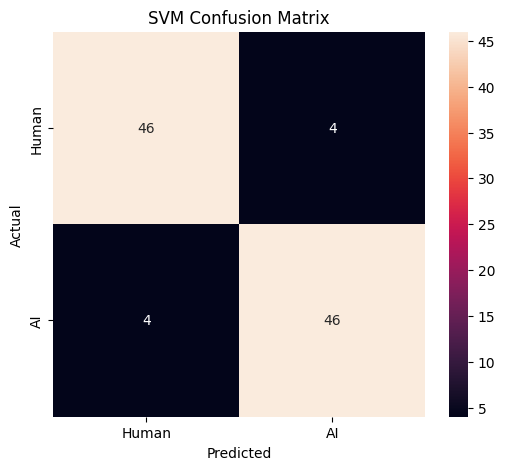

In [ ]:
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Human",
        "AI"
    ],
    yticklabels=[
        "Human",
        "AI"
    ]
)

plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

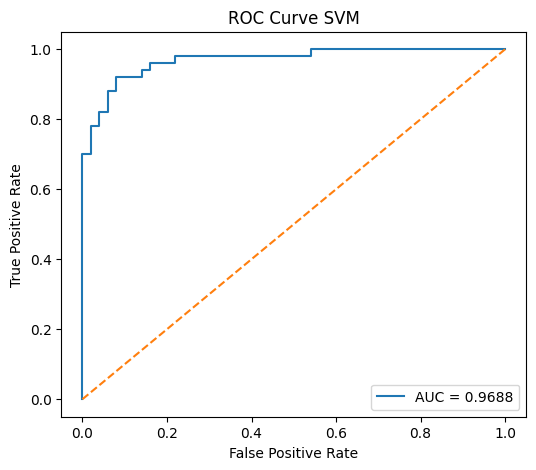

In [ ]:
y_prob = svm_model.predict_proba(
    X_test_tfidf
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve SVM")

plt.legend()

plt.show()

In [ ]:
print("="*50)
print("FINAL RESULTS")
print("="*50)

print(f"SVM Accuracy   : {test_acc:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"AUC Score      : {auc_score:.4f}")

FINAL RESULTS
SVM Accuracy   : 0.9200
Precision      : 0.9200
Recall         : 0.9200
F1 Score       : 0.9200
AUC Score      : 0.9688


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/FP_AI_2026/models",
    exist_ok=True
)

In [ ]:
joblib.dump(
    vectorizer,
    "/content/drive/MyDrive/FP_AI_2026/models/tfidf.pkl"
)

joblib.dump(
    svm_model,
    "/content/drive/MyDrive/FP_AI_2026/models/svm.pkl"
)

['/content/drive/MyDrive/FP_AI_2026/models/svm.pkl']

In [ ]:
sample_code = """
def bubble_sort(arr):
    n = len(arr)

    # Loop untuk seluruh elemen dalam list
    for i in range(n):
        # Flag untuk menandai apakah ada pertukaran di urutan ini
        # (Optimasi: jika tidak ada pertukaran, berarti array sudah terurut)
        swapped = False

        # Elemen terakhir i sudah pasti berada di posisi yang benar
        for j in range(0, n - i - 1):

            # Bandingkan elemen yang berdekatan
            if arr[j] > arr[j + 1]:
                # Tukar posisi jika elemen kiri lebih besar dari elemen kanan
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True

        # Jika tidak ada elemen yang ditukar pada loop dalam, keluar dari loop
        if not swapped:
            break

# --- Contoh Penggunaan ---
if __name__ == "__main__":
    angka = [64, 34, 25, 12, 22, 11, 90]

    print("Array sebelum diurutkan:")
    print(angka)

    bubble_sort(angka)

    print("\nArray setelah diurutkan (Bubble Sort):")
    print(angka)
"""


sample_vec = vectorizer.transform(
    [sample_code]
)

pred = svm_model.predict(
    sample_vec
)[0]

if pred == 0:
    print("Human Generated")
else:
    print("AI Generated")

AI Generated


In [ ]:
import time

training_time = end - start

inference_start = time.time()

_ = svm_model.predict(X_test_tfidf)
inference_end = time.time()
inference_time = inference_end - inference_start

svm_parameters = (
    svm_model.coef_.size +
    svm_model.intercept_.size
)

svm_results = {
    "Model": "SVM",

    "Accuracy": accuracy_score(
        y_test,
        test_pred
    ),

    "Precision": precision,

    "Recall": recall,

    "F1": f1,

    "AUC": auc_score,

    "Training_Time": training_time,

    "Inference_Time": inference_time,

    "Parameters": svm_parameters
}

In [ ]:
comparison_df = pd.DataFrame([
    svm_results
])

comparison_df

,Model,Accuracy,Precision,Recall,F1,AUC,Training_Time,Inference_Time,Parameters
0,SVM,0.92,0.92,0.92,0.92,0.9688,1.615009,0.037353,4900


In [ ]:
compare_path = (
    "/content/drive/MyDrive/FP_AI_2026/compare"
)

svm_df = pd.DataFrame(
    [svm_results]
)

svm_df.to_csv(
    f"{compare_path}/svm_results.csv",
    index=False
)

print(
    "SVM results saved!"
)

SVM results saved!
